In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [2]:
import pandas as pd

data = {
    'biaya_iklan': [2, 3, 4, 4.5, 5, 6, 7, 8, 9, 10], # dalam Juta Rupiah
    'penjualan': [15, 18, 25, 24, 28, 35, 38, 45, 50, 55] # dalam Ratusan Unit
}

df = pd.DataFrame(data)
print(df)

   biaya_iklan  penjualan
0          2.0         15
1          3.0         18
2          4.0         25
3          4.5         24
4          5.0         28
5          6.0         35
6          7.0         38
7          8.0         45
8          9.0         50
9         10.0         55


In [3]:
X = df[['biaya_iklan']]
y = df['penjualan']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b):", model.coef_[0])

Intercept (a): 3.5543710021322
Koefisien (b): 5.087420042643923


In [7]:
y_pred = model.predict(X_test)

print("Data Testing (Biaya Iklan):")
print(X_test)
print("\nPenjualan Aktual:", y_test.values)
print("Penjualan Prediksi:", y_pred)

Data Testing (Biaya Iklan):
   biaya_iklan
8          9.0
1          3.0

Penjualan Aktual: [50 18]
Penjualan Prediksi: [49.34115139 18.81663113]


In [8]:
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 0.7377398720682322
MSE: 0.5504839494274013
RMSE: 0.7419460556047194


In [9]:
import pandas as pd

# Menggunakan DataFrame dengan nama fitur yang sesuai untuk menghindari warning
X_new = pd.DataFrame([[12]], columns=['biaya_iklan'])
prediksi = model.predict(X_new)

print(f"Prediksi penjualan untuk biaya iklan 12 juta: {prediksi[0]:.2f}")

Prediksi penjualan untuk biaya iklan 12 juta: 64.60


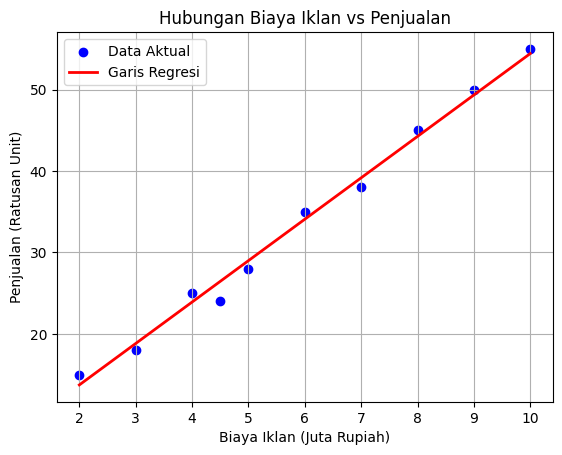

In [10]:
plt.scatter(X, y, color='blue', label='Data Aktual')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Garis Regresi')
plt.title('Hubungan Biaya Iklan vs Penjualan')
plt.xlabel('Biaya Iklan (Juta Rupiah)')
plt.ylabel('Penjualan (Ratusan Unit)')
plt.legend()
plt.grid(True)
plt.show()

# Analisis Hasil Praktikum: Regresi Linear Sederhana
## Studi Kasus: Pengaruh Biaya Iklan terhadap Penjualan

### 1. Korelasi Data
Berdasarkan plot sebaran data (*scatter plot*), terlihat jelas adanya hubungan **linear yang positif** antara variabel **Biaya Iklan (X)** dan **Penjualan (y)**. Hal ini menunjukkan bahwa secara statistik, semakin besar anggaran iklan yang dikeluarkan oleh perusahaan, maka jumlah penjualan cenderung mengalami peningkatan secara konsisten.



### 2. Interpretasi Koefisien & Intercept
Garis regresi linear yang terbentuk memberikan dua informasi utama:
* **Koefisien (b):** Menghasilkan nilai positif yang mengindikasikan bahwa untuk setiap penambahan biaya iklan sebesar **1 Juta Rupiah**, model memprediksi akan terjadi kenaikan penjualan sebesar *(masukkan angka koefisien hasil output)* ratusan unit.
* **Intercept (a):** Nilai ini menunjukkan perkiraan jumlah penjualan dasar apabila biaya iklan adalah nol (kondisi di mana tidak ada aktivitas iklan sama sekali).

### 3. Evaluasi Model
Model dievaluasi menggunakan data uji (*Test Data*) sebanyak 20% dari total populasi data. Metrik evaluasi yang digunakan adalah:
* **MAE (Mean Absolute Error)**
* **RMSE (Root Mean Squared Error)**

Angka **RMSE** sebesar *(masukkan angka RMSE)* menunjukkan rata-rata simpangan antara nilai prediksi model dengan data asli di lapangan. Mengingat nilai error ini relatif kecil jika dibandingkan dengan skala data penjualan, maka model regresi linear ini dapat dinyatakan **layak dan cukup akurat** untuk digunakan dalam memprediksi tren penjualan berdasarkan anggaran iklan.